In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [ ]:
import pandas as pd

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 8807
Columns: 12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
missing = df.isnull().sum()

print(missing)

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table

,Missing Values,Percentage
show_id,0,0.000000
type,0,0.000000
title,0,0.000000
director,2634,29.908028
cast,825,9.367549
country,831,9.435676
date_added,10,0.113546
release_year,0,0.000000
rating,4,0.045418
duration,3,0.034064


In [ ]:
data = df.copy()

In [ ]:
data = data.drop_duplicates()

In [ ]:
data["date_added"] = pd.to_datetime(
    data["date_added"],
    errors="coerce"
)

In [ ]:
data[["date_added", "release_year"]].head()

,date_added,release_year
0,2021-09-25,2020
1,2021-09-24,2021
2,2021-09-24,2021
3,2021-09-24,2021
4,2021-09-24,2021


In [ ]:
categorical_columns = [
    "director",
    "cast",
    "country",
    "rating"
]

for col in categorical_columns:
    data[col] = data[col].fillna("Unknown")

In [ ]:
print("Original shape:", df.shape)
print("Cleaned shape:", data.shape)

print("\nMissing values after cleaning:")
print(data.isnull().sum())

Original shape: (8807, 12)
Cleaned shape: (8807, 12)

Missing values after cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
dtype: int64


In [ ]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


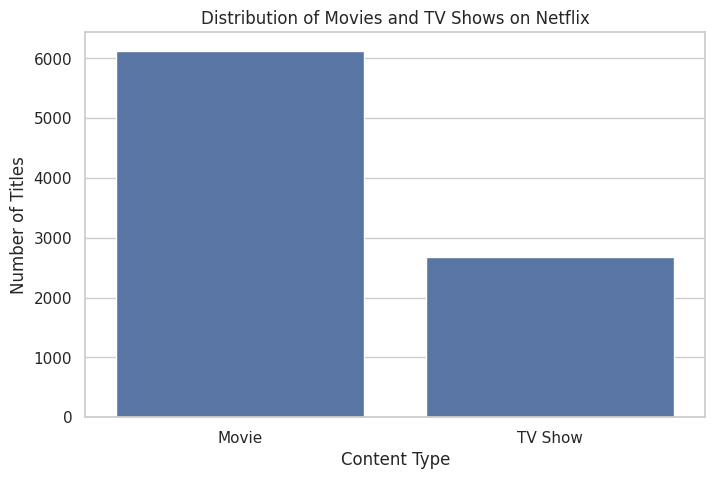

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="type"
)

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [ ]:
data["year_added"] = data["date_added"].dt.year

In [ ]:
content_by_year = (
    data.dropna(subset=["year_added"])
    .groupby("year_added")
    .size()
)

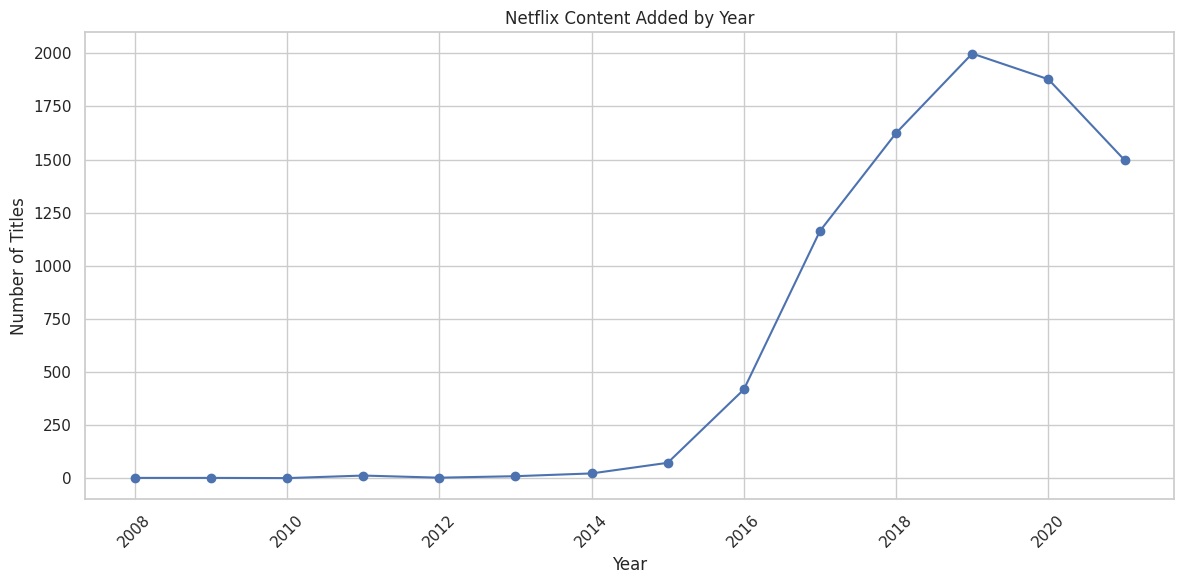

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    content_by_year.index,
    content_by_year.values,
    marker="o"
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
countries = (
    data["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

In [ ]:
country_counts = countries.value_counts().head(10)

country_counts

,count
country,
United States,3689
India,1046
Unknown,831
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231


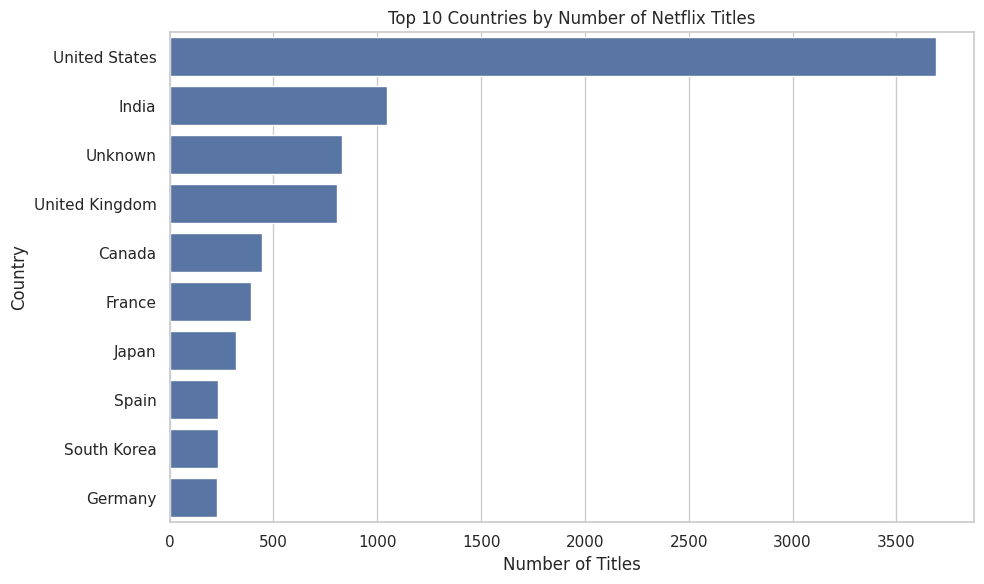

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [ ]:
genres = (
    data["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)

genre_counts = genres.value_counts().head(10)

genre_counts

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


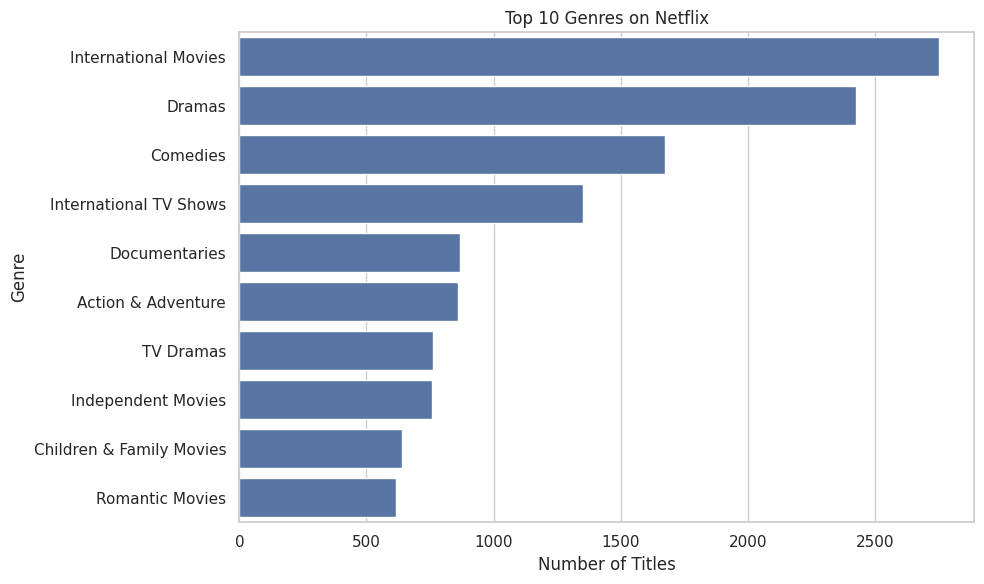

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

In [ ]:
rating_counts = data["rating"].value_counts().head(10)

rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


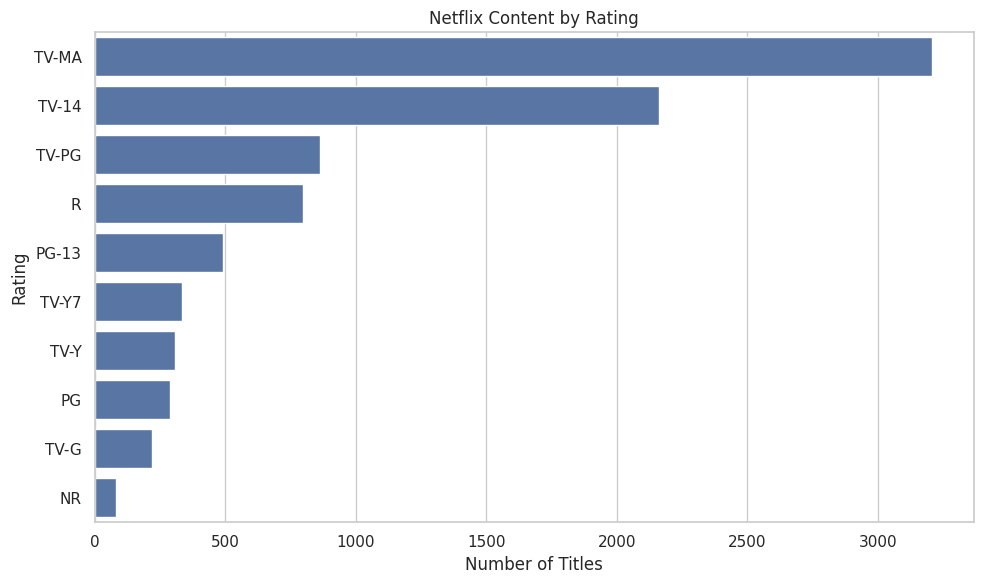

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index
)

plt.title("Netflix Content by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

In [ ]:
movies = data[data["type"] == "Movie"].copy()

In [ ]:
movies["duration_minutes"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [ ]:
movies["duration_minutes"].describe()

,duration_minutes
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


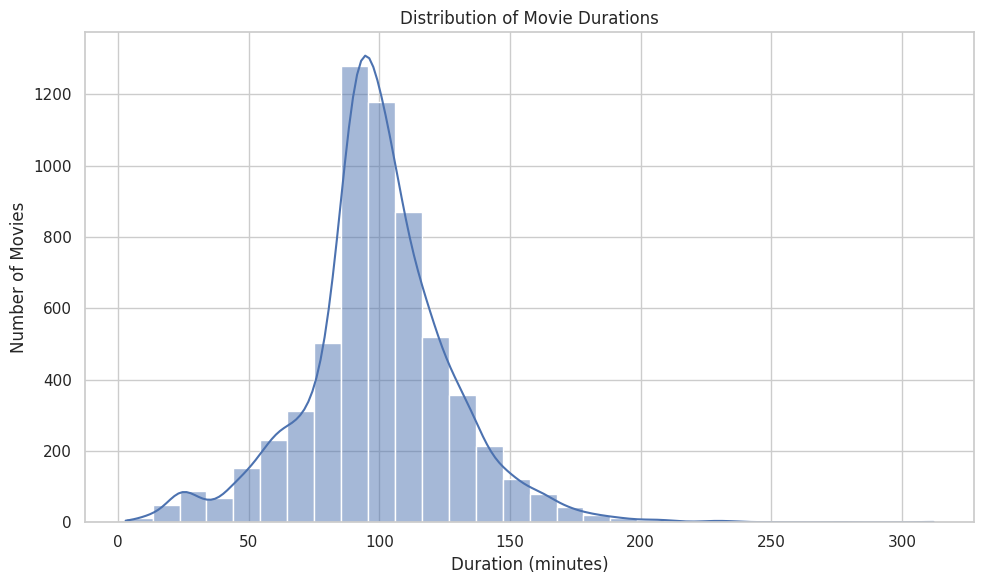

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    movies["duration_minutes"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

In [ ]:
timeline_data = data[
    ["release_year", "year_added"]
].dropna()

In [ ]:
heatmap_data = pd.crosstab(
    timeline_data["release_year"],
    timeline_data["year_added"]
)

In [ ]:
heatmap_data = heatmap_data.loc[
    heatmap_data.index >= 2000
]

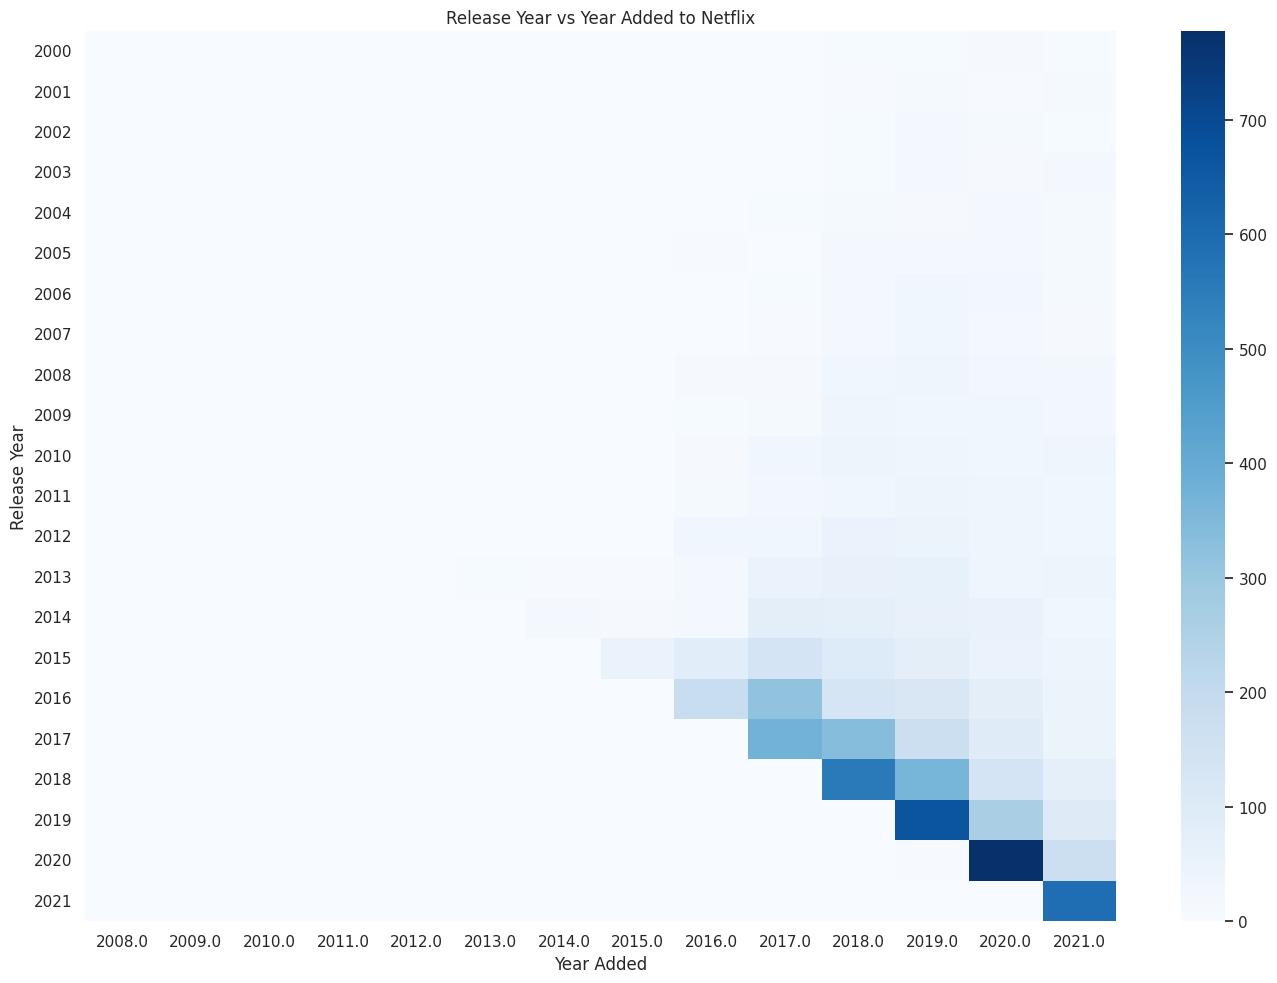

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_data,
    cmap="Blues"
)

plt.title("Release Year vs Year Added to Netflix")
plt.xlabel("Year Added")
plt.ylabel("Release Year")

plt.tight_layout()
plt.show()

In [ ]:
print("KEY INSIGHTS FROM THE NETFLIX DATASET")
print("-------------------------------------")

print("1. The dataset contains both Movies and TV Shows, with Movies representing a larger portion of the catalog.")

print("2. The number of titles added to Netflix varies across different years, showing changes in catalog expansion.")

print("3. A small number of countries contribute a large share of the titles represented in the dataset.")

print("4. Certain genres appear more frequently than others, showing the dominant content categories.")

print("5. Netflix content is distributed across different audience rating categories.")

print("6. Movie durations are concentrated within particular ranges, indicating common movie-length patterns.")

print("7. The relationship between release year and year added shows how both newer and older content are represented in the catalog.")

KEY INSIGHTS FROM THE NETFLIX DATASET
-------------------------------------
1. The dataset contains both Movies and TV Shows, with Movies representing a larger portion of the catalog.
2. The number of titles added to Netflix varies across different years, showing changes in catalog expansion.
3. A small number of countries contribute a large share of the titles represented in the dataset.
4. Certain genres appear more frequently than others, showing the dominant content categories.
5. Netflix content is distributed across different audience rating categories.
6. Movie durations are concentrated within particular ranges, indicating common movie-length patterns.
7. The relationship between release year and year added shows how both newer and older content are represented in the catalog.


In [ ]:
business_implications = [
    "Genre analysis can help understand which types of content are strongly represented in the catalog.",
    "Country-level analysis can provide insights into the geographic diversity of available content.",
    "Rating analysis can help understand the audience categories represented in the dataset.",
    "Movie-duration analysis provides information about common content-length patterns.",
    "Year-based analysis can help study how the Netflix catalog has changed over time.",
    "Release-year and addition-year analysis can provide insights into the mixture of older and newer content."
]

for i, implication in enumerate(business_implications, 1):
    print(f"{i}. {implication}")

1. Genre analysis can help understand which types of content are strongly represented in the catalog.
2. Country-level analysis can provide insights into the geographic diversity of available content.
3. Rating analysis can help understand the audience categories represented in the dataset.
4. Movie-duration analysis provides information about common content-length patterns.
5. Year-based analysis can help study how the Netflix catalog has changed over time.
6. Release-year and addition-year analysis can provide insights into the mixture of older and newer content.


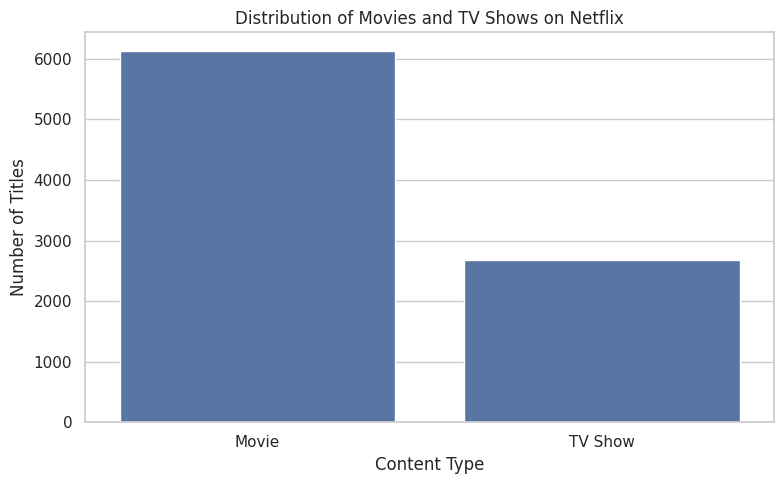

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=data, x="type")

plt.title("Distribution of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()

plt.savefig("visualization_1_movies_vs_tv_shows.png", dpi=300, bbox_inches="tight")

plt.show()

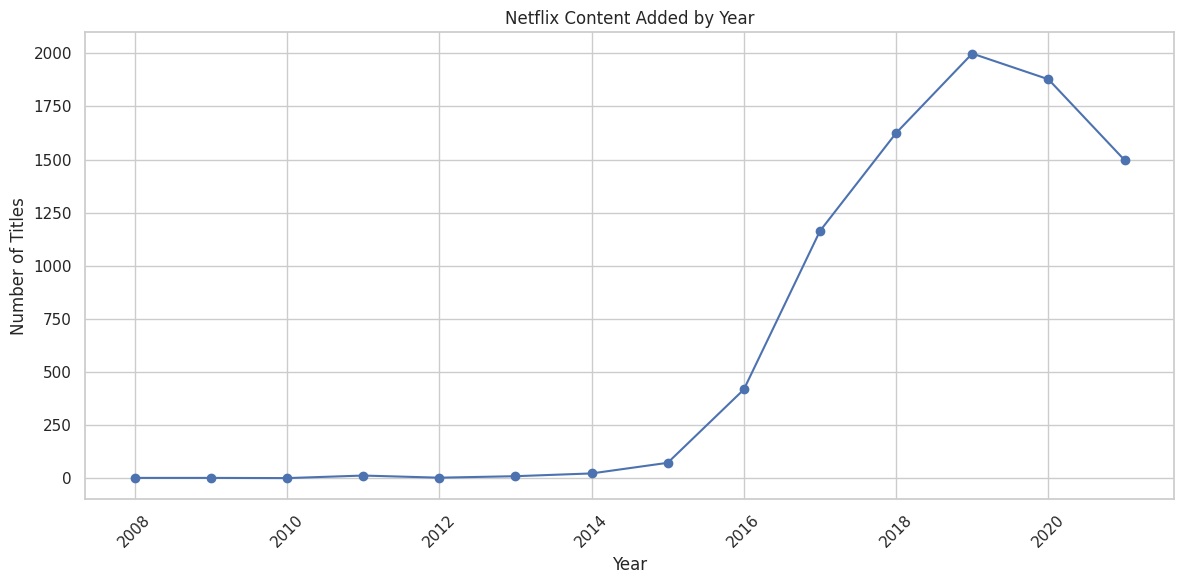

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    content_by_year.index,
    content_by_year.values,
    marker="o"
)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
plt.tight_layout()

plt.savefig("visualization_2_content_added_by_year.png", dpi=300, bbox_inches="tight")

plt.show()

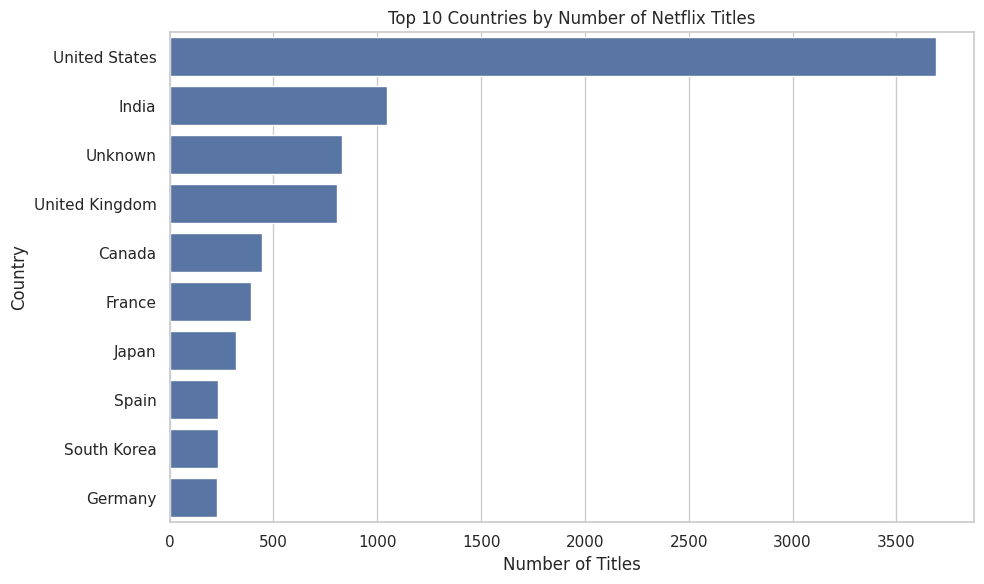

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()
plt.tight_layout()

plt.savefig("visualization_3_top_10_countries.png", dpi=300, bbox_inches="tight")

plt.show()

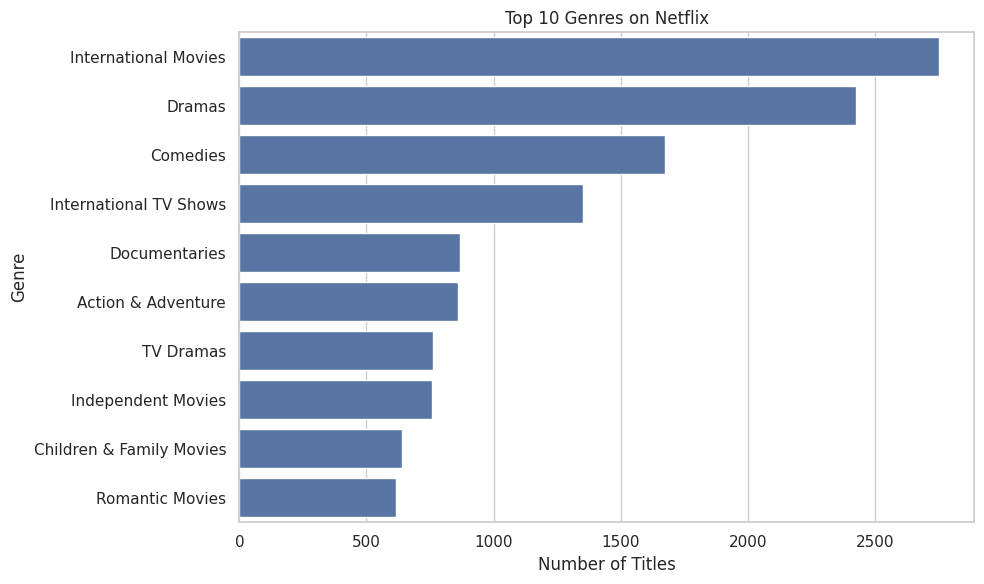

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()
plt.tight_layout()

plt.savefig("visualization_4_top_10_genres.png", dpi=300, bbox_inches="tight")

plt.show()

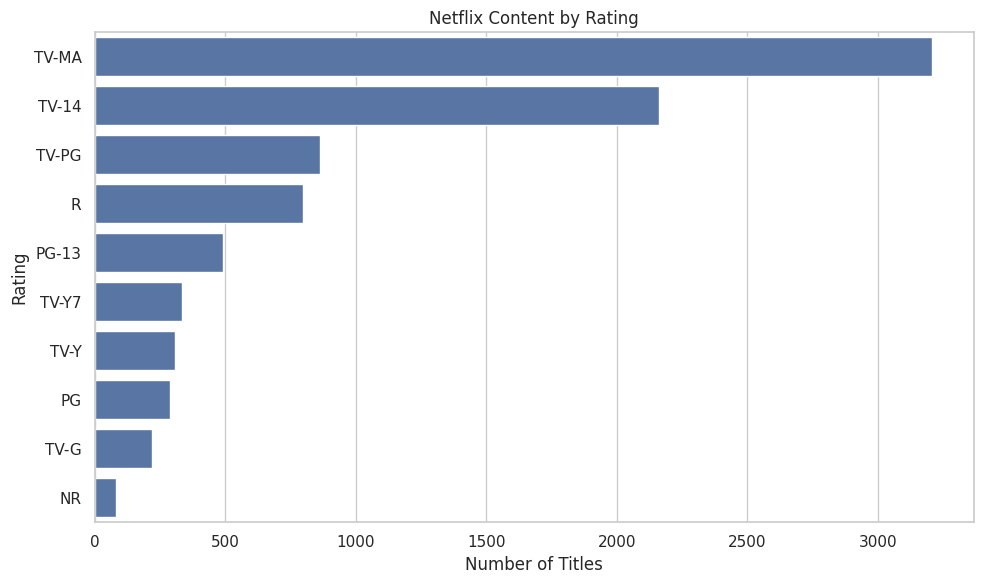

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index
)

plt.title("Netflix Content by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()
plt.tight_layout()

plt.savefig("visualization_5_rating_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

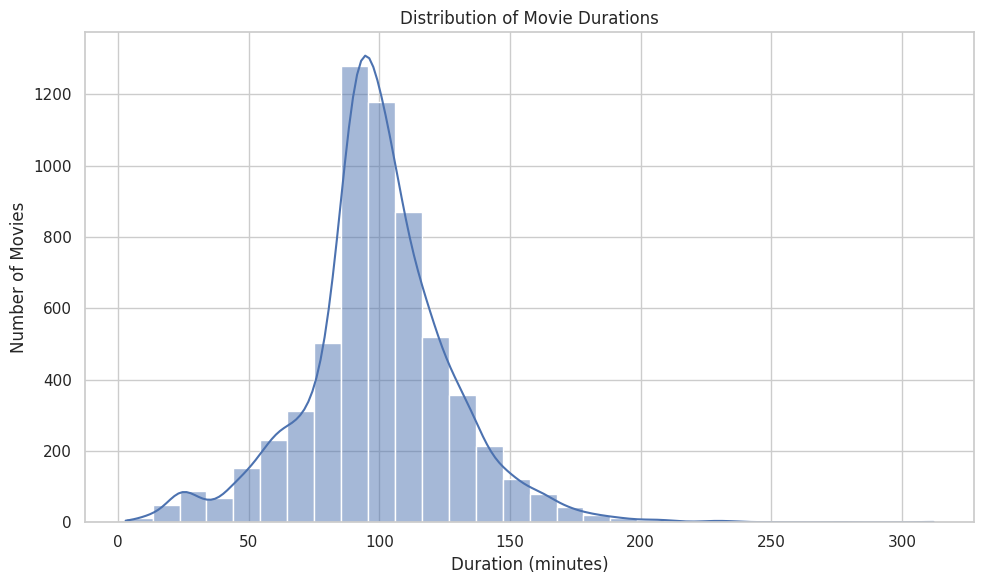

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    movies["duration_minutes"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()
plt.tight_layout()

plt.savefig("visualization_6_movie_duration.png", dpi=300, bbox_inches="tight")

plt.show()

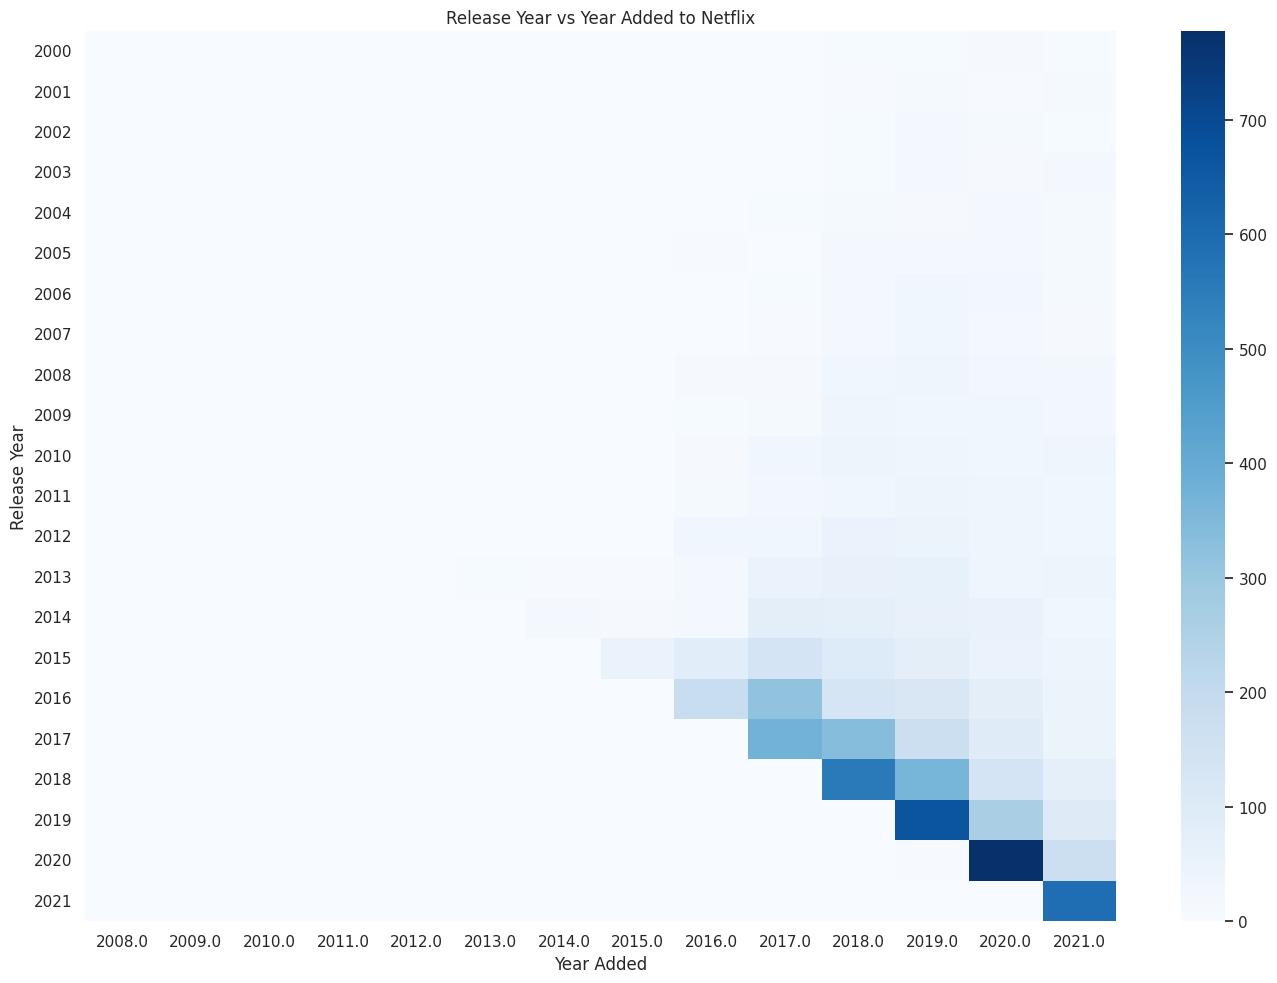

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    heatmap_data,
    cmap="Blues"
)

plt.title("Release Year vs Year Added to Netflix")
plt.xlabel("Year Added")
plt.ylabel("Release Year")

plt.tight_layout()
plt.show()
plt.tight_layout()

plt.savefig("visualization_7_release_year_vs_year_added.png", dpi=300, bbox_inches="tight")

plt.show()